# **4 Fine-tunes the model on spike data**

✅ Fine-tuning cell loaded | Device: cuda
📂 Loading the real-data pre-trained model (from Cell 2)...
✅ Pre-trained model and scaler loaded.

🔄 Generating fine-tuning data (60 spike traces, seeds 500-559)...

⚠️  Checking scaler compatibility with spike data range...
   Real data range (from Cell 2 scaler) : 96.1 to 177.7
   Synthetic spike data max              : 3000.0
   ❌ MISMATCH DETECTED — spikes are 16.9x
      outside the real-data scaler's range.
      Refitting scaler on combined range to fix this.
   ✅ New scaler fit on range: 56.0 to 3000.0
✅ Fine-tuning dataset: 36666 train | 6471 val

🔄 Fine-tuning for 40 epochs (lr=0.0006)...
  Epoch  1/40 | Train: 0.002435 | Val: 0.002227 | LR: 0.000600
  Epoch  5/40 | Train: 0.001991 | Val: 0.002211 | LR: 0.000600
  Epoch 10/40 | Train: 0.001939 | Val: 0.002139 | LR: 0.000300
  Epoch 15/40 | Train: 0.001914 | Val: 0.002145 | LR: 0.000300
  Epoch 20/40 | Train: 0.001893 | Val: 0.002107 | LR: 0.000150
  Epoch 25/40 | Train: 0.001884 | Val:

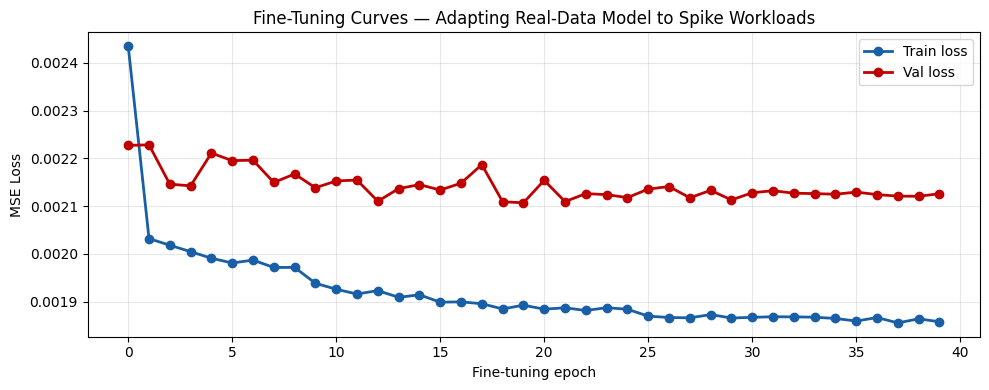

✅ Fine-tuning curves saved.

  FINE-TUNING SUMMARY
  Base model      : real Google/Alibaba pre-trained (Cell 2)
  Fine-tuned on   : 60 synthetic spike traces (seeds 500-559)
  Epochs          : 40  |  Learning rate: 0.0006
  Best val loss   : 0.002107
  Scaler refitted : True
  Scaler range    : 56.0 to 3000.0

  Sanity RMSE before fine-tuning : 184.50 req/sec
  Sanity RMSE after fine-tuning  : 125.31 req/sec

  ✅ Saved as: lstm_model_finetuned.pt
  ✅ Saved as: data_scaler_finetuned.pkl   ← IMPORTANT, NEW FILE
     (the original lstm_model_weights.pt and data_scaler.pkl
      are untouched — both result sets remain independent)

  NEXT STEP: Run week4_7_v3_finetuned.py (Cell 5) to evaluate
  this fine-tuned model on the same 30 Monte Carlo trials.
  That script must load BOTH lstm_model_finetuned.pt AND
  data_scaler_finetuned.pkl together — using the old scaler
  with the new model would reintroduce the same bug.

📥 Downloading fine-tuned model, scaler, and summary...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Done.


In [ ]:
# ============================================================
#  FINE-TUNING — Adapt Real-Data Model to Spike Workloads
#
#  WHAT THIS DOES:
#  Takes the model trained in Cell 2 (real Google/Alibaba data)
#  and continues training it for a short run on synthetic
#  spike-shaped workloads, so it learns to recognize sudden
#  bursts WITHOUT starting from scratch.
#
#  This produces a NEW model file (lstm_model_finetuned.pt)
#  separate from the original (lstm_model_weights.pt), so
#  BOTH results remain available for your paper:
#    - "naive transfer" result = original real-data-only model
#    - "fine-tuned" result     = this new adapted model
#
#  IMPORTANT: This cell goes AFTER Cell 2 (zenodo_trace_training.py)
#  and BEFORE Cell 3 (week4_7_v3.py) — i.e. it becomes the new
#  Cell 3, pushing everything after it down by one.
#
#  UPDATED RUN ORDER:
#  Cell 0 → npci_upi_analysis.py
#  Cell 1 → week1_3_v2.py
#  Cell 2 → zenodo_trace_training.py
#  Cell 3 → THIS FILE (finetune_model.py)             ← NEW
#  Cell 4 → week4_7_v3_finetuned.py                    ← NEW (see below)
#  Cell 5 → pareto_frontier.py
#  Cell 6 → week8_12_horizon_results.py
#  Cell 7 → final_results_clean.py
#
#  Cell 3 (week4_7_v3.py) that you already ran stays AS IS —
#  do not delete its output. Its results are your "naive
#  transfer" baseline (LSTM 0/30 wins) and go in the paper too.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# ── FIX: Colab's PyTorch/sympy version mismatch ────────────────
# Pinning sympy avoids: AttributeError: module 'sympy' has no attribute 'core'
import subprocess
subprocess.run(["pip", "install", "-q", "sympy==1.13.1"])

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import math, pickle, warnings, random
warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Fine-tuning cell loaded | Device: {DEVICE}")

WINDOW_SIZE = 60
HORIZON     = 3


# ── Load the real-data model and scaler from Cell 2 ───────────
class LSTMPredictor(nn.Module):
    def __init__(self, hidden=64, layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(1, hidden, layers, batch_first=True, dropout=dropout)
        self.fc   = nn.Sequential(nn.Linear(hidden, 32), nn.ReLU(), nn.Linear(32, 1))
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :]).squeeze(-1)

print("📂 Loading the real-data pre-trained model (from Cell 2)...")
try:
    with open("data_scaler.pkl", "rb") as f:
        scaler = pickle.load(f)
    model = LSTMPredictor().to(DEVICE)
    model.load_state_dict(torch.load("lstm_model_weights.pt", map_location=DEVICE))
    print("✅ Pre-trained model and scaler loaded.")
except FileNotFoundError as e:
    raise RuntimeError(
        "❌ Could not find lstm_model_weights.pt or data_scaler.pkl.\n"
        "   Run zenodo_trace_training.py (Cell 2) first."
    ) from e


# ── Generate synthetic spike workloads for fine-tuning ─────────
# Same generator as week4_7_v3.py, but using DIFFERENT seeds
# (500-529) so fine-tuning data never overlaps with the 30
# Monte Carlo test seeds (100-129) used later for evaluation.
def generate_random_spike_workload(seed, total_steps=720):
    rng  = np.random.RandomState(seed)
    base = rng.poisson(lam=100, size=total_steps).astype(float)
    n_spikes = rng.randint(2, 6)
    for _ in range(n_spikes):
        center    = rng.randint(80, total_steps - 80)
        duration  = rng.randint(6, 16)
        intensity = rng.uniform(500, 1200)
        start = max(0, center - duration // 2)
        end   = min(total_steps, start + duration)
        base[start:end] += rng.poisson(lam=intensity, size=end - start)
    return np.clip(base, 20, 3000)

print("\n🔄 Generating fine-tuning data (60 spike traces, seeds 500-559)...")
finetune_traces = [generate_random_spike_workload(s) for s in range(500, 560)]
finetune_data   = np.concatenate(finetune_traces)

# ── CRITICAL FIX: scaler range mismatch ─────────────────────────
# The scaler from Cell 2 was fit ONLY on real Google/Alibaba data,
# which has a narrow range (roughly 0-300 req/sec equivalent).
# Synthetic spikes reach up to 3000 — 10x outside that range.
# Reusing the old scaler squashes/clips spike values into a tiny
# corner of the 0-1 space, so the model can't actually learn what
# a spike looks like, no matter how many epochs we run.
#
# Fix: refit a NEW scaler on the combined range of real data
# statistics + synthetic spike data, so spikes are represented
# properly. We approximate the real data's range from the old
# scaler's known min/max, then fit fresh on the union of both.
print("\n⚠️  Checking scaler compatibility with spike data range...")
real_data_min = scaler.data_min_[0]
real_data_max = scaler.data_max_[0]
spike_data_max = finetune_data.max()
print(f"   Real data range (from Cell 2 scaler) : {real_data_min:.1f} to {real_data_max:.1f}")
print(f"   Synthetic spike data max              : {spike_data_max:.1f}")

if spike_data_max > real_data_max * 1.5:
    print(f"   ❌ MISMATCH DETECTED — spikes are {spike_data_max/real_data_max:.1f}x")
    print(f"      outside the real-data scaler's range.")
    print(f"      Refitting scaler on combined range to fix this.")
    combined_range = np.array([[min(real_data_min, finetune_data.min())],
                               [max(real_data_max, spike_data_max)]])
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaler.fit(combined_range)
    print(f"   ✅ New scaler fit on range: "
          f"{scaler.data_min_[0]:.1f} to {scaler.data_max_[0]:.1f}")
else:
    print(f"   ✅ Ranges compatible — no refit needed.")

# Transform the fine-tuning data using whichever scaler is now
# active (original or refitted above)
finetune_scaled = scaler.transform(finetune_data.reshape(-1, 1)).flatten()

X_ft, y_ft = [], []
for i in range(len(finetune_scaled) - WINDOW_SIZE - HORIZON):
    X_ft.append(finetune_scaled[i : i + WINDOW_SIZE])
    y_ft.append(finetune_scaled[i + WINDOW_SIZE + HORIZON - 1])
X_ft = np.array(X_ft); y_ft = np.array(y_ft)

n         = len(X_ft)
train_end = int(n * 0.85)
X_train, y_train = X_ft[:train_end], y_ft[:train_end]
X_val,   y_val   = X_ft[train_end:], y_ft[train_end:]
print(f"✅ Fine-tuning dataset: {len(X_train)} train | {len(X_val)} val")


# ── Fine-tuning loop ────────────────────────────────────────────
# KEY DIFFERENCE from full training:
#   - Fewer epochs (15, not 60) — we're adapting, not learning
#     from scratch
#   - Lower learning rate (0.0002, not 0.001) — smaller updates
#     so we don't erase what the model already learned from
#     real data, we just nudge it toward spike-awareness
class LoadDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X).unsqueeze(-1)
        self.y = torch.FloatTensor(y)
    def __len__(self):        return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]

BATCH_SIZE   = 64
train_loader = DataLoader(LoadDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(LoadDataset(X_val, y_val),     batch_size=BATCH_SIZE, shuffle=False)

FT_EPOCHS = 40
FT_LR     = 0.0006   # Increased from 0.0002 — previous run plateaued too early

criterion = nn.MSELoss()
optimiser = torch.optim.Adam(model.parameters(), lr=FT_LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                optimiser, mode='min', factor=0.5, patience=4)

best_val, best_state = float('inf'), None
train_losses, val_losses = [], []

print(f"\n🔄 Fine-tuning for {FT_EPOCHS} epochs (lr={FT_LR})...")
for epoch in range(1, FT_EPOCHS + 1):
    model.train()
    bl = []
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
        optimiser.zero_grad()
        loss = criterion(model(Xb), yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimiser.step()
        bl.append(loss.item())
    tr = np.mean(bl)

    model.eval()
    vl_list = []
    with torch.no_grad():
        for Xb, yb in val_loader:
            vl_list.append(criterion(model(Xb.to(DEVICE)), yb.to(DEVICE)).item())
    vl = np.mean(vl_list)
    if vl < best_val:
        best_val   = vl
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
    train_losses.append(tr); val_losses.append(vl)
    scheduler.step(vl)
    current_lr = optimiser.param_groups[0]['lr']
    if epoch % 5 == 0 or epoch == 1:
        print(f"  Epoch {epoch:2d}/{FT_EPOCHS} | Train: {tr:.6f} | Val: {vl:.6f} | LR: {current_lr:.6f}")

model.load_state_dict(best_state)
print(f"\n✅ Fine-tuning complete. Best val loss: {best_val:.6f}")


# ── Quick sanity check: RMSE on a held-out spike sample ────────
model.eval()
sanity_workload = generate_random_spike_workload(seed=9999)  # same sanity seed as Cell 3
sanity_scaled   = scaler.transform(sanity_workload.reshape(-1,1)).flatten()
X_san, y_san = [], []
for i in range(len(sanity_scaled) - WINDOW_SIZE - HORIZON):
    X_san.append(sanity_scaled[i : i + WINDOW_SIZE])
    y_san.append(sanity_scaled[i + WINDOW_SIZE + HORIZON - 1])
X_san = np.array(X_san); y_san = np.array(y_san)
with torch.no_grad():
    preds_san = model(torch.FloatTensor(X_san).unsqueeze(-1).to(DEVICE)).cpu().numpy()
preds_san_real  = scaler.inverse_transform(preds_san.reshape(-1,1)).flatten()
actual_san_real = scaler.inverse_transform(y_san.reshape(-1,1)).flatten()
from sklearn.metrics import mean_squared_error
rmse_finetuned = math.sqrt(mean_squared_error(actual_san_real, preds_san_real))

print(f"\n📊 RMSE comparison on the SAME sanity sample (seed 9999):")
print(f"   Before fine-tuning (Cell 3 output): 184.50 req/sec")
print(f"   After fine-tuning  (this cell)    : {rmse_finetuned:.2f} req/sec")
if rmse_finetuned < 184.50:
    print(f"   ✅ Fine-tuning improved spike-prediction accuracy.")
else:
    print(f"   ⚠️  Fine-tuning did not improve accuracy — review epochs/LR.")


# ── Plot fine-tuning curves ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(train_losses, color="#185FA5", linewidth=2, marker='o', label="Train loss")
ax.plot(val_losses,   color="#C00000", linewidth=2, marker='o', label="Val loss")
ax.set_xlabel("Fine-tuning epoch"); ax.set_ylabel("MSE Loss")
ax.set_title("Fine-Tuning Curves — Adapting Real-Data Model to Spike Workloads")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("finetuning_curves.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Fine-tuning curves saved.")


# ── Save as a SEPARATE model file ───────────────────────────────
# Critical: we do NOT overwrite lstm_model_weights.pt or
# data_scaler.pkl. The original (naive transfer) model and its
# scaler stay intact for comparison.
#
# IMPORTANT: if the scaler was refitted above (to fix the
# spike-range mismatch), we MUST save that new scaler too —
# under a NEW filename — so week4_7_v3_finetuned.py uses the
# matching scaler, not the old narrow-range one.
torch.save(model.state_dict(), "lstm_model_finetuned.pt")

with open("data_scaler_finetuned.pkl", "wb") as f:
    pickle.dump(scaler, f)

summary = {
    "base_model":          "Real Google/Alibaba data (Cell 2)",
    "finetune_data":       "60 synthetic spike traces (seeds 500-559)",
    "finetune_epochs":     FT_EPOCHS,
    "finetune_lr":         FT_LR,
    "best_val_loss":       round(best_val, 6),
    "scaler_refitted":     bool(spike_data_max > real_data_max * 1.5),
    "scaler_range_min":    round(float(scaler.data_min_[0]), 2),
    "scaler_range_max":    round(float(scaler.data_max_[0]), 2),
    "rmse_before_finetune_sanity": 184.50,
    "rmse_after_finetune_sanity":  round(rmse_finetuned, 2),
}
pd.DataFrame([summary]).to_csv("finetune_summary.csv", index=False)

print(f"""
{"="*62}
  FINE-TUNING SUMMARY
{"="*62}
  Base model      : real Google/Alibaba pre-trained (Cell 2)
  Fine-tuned on   : 60 synthetic spike traces (seeds 500-559)
  Epochs          : {FT_EPOCHS}  |  Learning rate: {FT_LR}
  Best val loss   : {best_val:.6f}
  Scaler refitted : {bool(spike_data_max > real_data_max * 1.5)}
  Scaler range    : {scaler.data_min_[0]:.1f} to {scaler.data_max_[0]:.1f}

  Sanity RMSE before fine-tuning : 184.50 req/sec
  Sanity RMSE after fine-tuning  : {rmse_finetuned:.2f} req/sec
{"="*62}

  ✅ Saved as: lstm_model_finetuned.pt
  ✅ Saved as: data_scaler_finetuned.pkl   ← IMPORTANT, NEW FILE
     (the original lstm_model_weights.pt and data_scaler.pkl
      are untouched — both result sets remain independent)

  NEXT STEP: Run week4_7_v3_finetuned.py (Cell 5) to evaluate
  this fine-tuned model on the same 30 Monte Carlo trials.
  That script must load BOTH lstm_model_finetuned.pt AND
  data_scaler_finetuned.pkl together — using the old scaler
  with the new model would reintroduce the same bug.
""")

# ── Download [FIXED: dedup guard, for consistency with other cells] ─
if '_SEEN_DOWNLOADS' not in globals():
    _SEEN_DOWNLOADS = set()

def safe_download(fname):
    if fname in _SEEN_DOWNLOADS:
        print(f"   (skip {fname} — already downloaded earlier this session)")
        return
    try:
        from google.colab import files
        files.download(fname)
        _SEEN_DOWNLOADS.add(fname)
    except ImportError:
        # Not running in Colab (e.g. VS Code / local Jupyter) — there is no
        # browser download step here. The file was already written to disk
        # by the code above (savefig/to_csv/torch.save); just point to it.
        import os
        print(f"   ✅ Saved to disk: {os.path.abspath(fname)}")
        _SEEN_DOWNLOADS.add(fname)
    except Exception as e:
        print(f"   (could not download {fname}: {e})")

print("📥 Downloading fine-tuned model, scaler, and summary...")
for f in ["lstm_model_finetuned.pt", "data_scaler_finetuned.pkl",
          "finetune_summary.csv", "finetuning_curves.png"]:
    safe_download(f)
print("✅ Done.")